# M-03 Pose Estimation

Person Detection crop을 입력으로 받아 RTMPose-t의 COCO-17 keypoint를 추출하기 위한 baseline

## 구현 범위

1. Colab 또는 macOS 로컬 경로 설정
2. 최소 실행 package 설치
3. ONNX Runtime 실행 provider 확인
4. OpenMMLab RTMPose-t ONNX 모델 무결성 확인
5. Person Detection bbox 입력 계약 정의
6. bbox padding과 affine transform 전처리
7. RTMPose 추론과 SimCC decode
8. COCO-17 keypoint 시각화와 latency 검증
9. M-04 전달용 출력 계약 확인

# 1. 환경 설정

Colab에서는 Google Drive를 mount하고, 로컬에서는 현재 위치부터 Git 저장소 root를 탐색

In [1]:
import importlib.util
import os
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from google.colab import drive

    DRIVE_MOUNT_POINT = Path("/content/drive")
    drive.mount(str(DRIVE_MOUNT_POINT))
    PROJECT_ROOT = (
        DRIVE_MOUNT_POINT / "MyDrive" / "Colab Notebooks" / "wardy-pose-fall"
    )
    runtime_name = "Google Colab"
else:
    def find_project_root(start_path: Path) -> Path:
        for candidate in (start_path, *start_path.parents):
            if (candidate / ".git").exists() and (candidate / "ml" / "notebook").is_dir():
                return candidate
        raise FileNotFoundError(
            "wardy 저장소 내부에서 Jupyter 실행 또는 WARDY_PROJECT_ROOT 설정 필요"
        )

    search_start = Path(
        os.environ.get("WARDY_PROJECT_ROOT", Path.cwd())
    ).expanduser().resolve()
    PROJECT_ROOT = find_project_root(search_start)
    runtime_name = "Local Jupyter"

REQUIREMENTS_PATH = PROJECT_ROOT / "ml" / "requirements" / "m03.txt"
MODEL_DIR = PROJECT_ROOT / "ml" / "checkpoints" / "rtmpose-t-onnx"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Runtime: {runtime_name}")
print(f"Project repository: {PROJECT_ROOT.name}")
print(f"Requirements: {REQUIREMENTS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Model cache: {MODEL_DIR.relative_to(PROJECT_ROOT)}")

Runtime: Local Jupyter
Project repository: wardy-pose-fall
Requirements: ml/requirements/m03.txt
Model cache: ml/checkpoints/rtmpose-t-onnx


## 최소 package 설치

RTMPose ONNX 추론에 필요한 package만 설치. `mmcv`, `mmdet`, `mmpose`, PyTorch C++ extension compile은 사용하지 않음

In [2]:
%pip install --quiet --disable-pip-version-check -r {REQUIREMENTS_PATH}

Note: you may need to restart the kernel to use updated packages.


## ONNX Runtime provider 확인

Apple Silicon에서는 CoreML을 우선 사용하고, 지원하지 않는 연산은 CPU로 fallback

In [3]:
import platform
import sys
from importlib.metadata import version

import cv2
import numpy as np
import onnxruntime as ort

available_providers = ort.get_available_providers()
if platform.system() == "Darwin" and "CoreMLExecutionProvider" in available_providers:
    SESSION_PROVIDERS = ["CoreMLExecutionProvider", "CPUExecutionProvider"]
else:
    SESSION_PROVIDERS = ["CPUExecutionProvider"]

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Machine: {platform.machine()}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"ONNX Runtime: {version('onnxruntime')}")
print(f"Available providers: {available_providers}")
print(f"Selected providers: {SESSION_PROVIDERS}")

Python: 3.10.20
Platform: macOS-26.5.2-arm64-arm-64bit
Machine: arm64
NumPy: 1.26.4
OpenCV: 4.11.0
ONNX Runtime: 1.23.2
Available providers: ['CoreMLExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Selected providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']


# 2. RTMPose-t baseline

OpenMMLab이 배포한 `RTMPose-t 256x192 COCO-17` ONNX archive를 내려받아 SHA-256 검증 후 추론 session 생성

In [4]:
import hashlib
from tempfile import NamedTemporaryFile
from urllib.request import urlretrieve
from zipfile import ZipFile

MODEL_URL = (
    "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/"
    "rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504.zip"
)
ARCHIVE_PATH = MODEL_DIR / "rtmpose-t.zip"
MODEL_PATH = (
    MODEL_DIR
    / "20230831"
    / "rtmpose_onnx"
    / "rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504"
    / "end2end.onnx"
)
ARCHIVE_SHA256 = "937003a70832d9cc34ea16927f504792f3133e92dda1b9c626236bbbe9e805cb"
MODEL_SHA256 = "a6c2f6a3896a4d51131d14d7a80a3d08b50f559af5a58a45d5b098aef510a70f"

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

if ARCHIVE_PATH.exists() and sha256(ARCHIVE_PATH) == ARCHIVE_SHA256:
    archive_state = "cached"
else:
    with NamedTemporaryFile(dir=MODEL_DIR, suffix=".part", delete=False) as file:
        download_path = Path(file.name)
    try:
        urlretrieve(MODEL_URL, download_path)
        downloaded_hash = sha256(download_path)
        if downloaded_hash != ARCHIVE_SHA256:
            raise RuntimeError(f"Archive SHA-256 mismatch: {downloaded_hash}")
        download_path.replace(ARCHIVE_PATH)
    finally:
        download_path.unlink(missing_ok=True)
    archive_state = "downloaded"

archive_hash = sha256(ARCHIVE_PATH)

if not MODEL_PATH.exists():
    with ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(MODEL_DIR)

model_hash = sha256(MODEL_PATH)
if model_hash != MODEL_SHA256:
    raise RuntimeError(f"Model SHA-256 mismatch: {model_hash}")

pose_session = ort.InferenceSession(
    str(MODEL_PATH),
    providers=SESSION_PROVIDERS,
)

input_specs = [(item.name, item.shape, item.type) for item in pose_session.get_inputs()]
output_specs = [(item.name, item.shape, item.type) for item in pose_session.get_outputs()]

print(f"Model archive: {archive_state}")
print(f"Archive SHA-256: {archive_hash}")
print(f"Model SHA-256: {model_hash}")
print(f"Session providers: {pose_session.get_providers()}")
print(f"Input: {input_specs}")
print(f"Outputs: {output_specs}")
print("RTMPose-t session: ready")

Model archive: cached
Archive SHA-256: 937003a70832d9cc34ea16927f504792f3133e92dda1b9c626236bbbe9e805cb
Model SHA-256: a6c2f6a3896a4d51131d14d7a80a3d08b50f559af5a58a45d5b098aef510a70f
Session providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
Input: [('input', ['batch', 3, 256, 192], 'tensor(float)')]
Outputs: [('simcc_x', ['batch', 'MatMulsimcc_x_dim_1', 384], 'tensor(float)'), ('simcc_y', ['batch', 'MatMulsimcc_x_dim_1', 512], 'tensor(float)')]
RTMPose-t session: ready


2026-08-11 09:51:11.406 Python[95515:33416008] 2026-08-11 09:51:11.404163 [W:onnxruntime:, coreml_execution_provider.cc:113 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 5 number of nodes in the graph: 168 number of nodes supported by CoreML: 125


# 3. Person Detection 입력 계약

M-01은 사람별 `bbox_xyxy`와 추적 정보를 전달하고, M-03은 동일한 `track_id`에 COCO-17 keypoint를 결합한다. 이 Notebook에서는 공식 MMPose 예제 이미지와 고정 bbox로 계약을 검증한다.

In [5]:
SAMPLE_URL = (
    "https://raw.githubusercontent.com/open-mmlab/mmpose/"
    "759b39c13fea6ba094afc1fa932f51dc1b11cbf9/"
    "tests/data/coco/000000000785.jpg"
)
SAMPLE_PATH = MODEL_DIR / "000000000785.jpg"
SAMPLE_SHA256 = "83981537a7baeafbeb9c8cb67b3484dc26433f574b3685d021fa537e277e4726"

if SAMPLE_PATH.exists() and sha256(SAMPLE_PATH) == SAMPLE_SHA256:
    sample_state = "cached"
else:
    with NamedTemporaryFile(dir=MODEL_DIR, suffix=".part", delete=False) as file:
        sample_download_path = Path(file.name)
    try:
        urlretrieve(SAMPLE_URL, sample_download_path)
        sample_hash = sha256(sample_download_path)
        if sample_hash != SAMPLE_SHA256:
            raise RuntimeError(f"Sample SHA-256 mismatch: {sample_hash}")
        sample_download_path.replace(SAMPLE_PATH)
    finally:
        sample_download_path.unlink(missing_ok=True)
    sample_state = "downloaded"

frame_bgr = cv2.imread(str(SAMPLE_PATH))
if frame_bgr is None:
    raise RuntimeError(f"Unable to read sample image: {SAMPLE_PATH}")

person_input = {
    "frame_id": "m03-official-sample",
    "timestamp_ms": 0,
    "track_id": 1,
    "bbox_xyxy": np.array([250, 35, 505, 420], dtype=np.float32),
    "frame_width": frame_bgr.shape[1],
    "frame_height": frame_bgr.shape[0],
}

print(f"Sample image: {sample_state}")
print(f"Sample SHA-256: {sha256(SAMPLE_PATH)}")
print(f"Frame shape: {frame_bgr.shape}")
print(f"Person input: {person_input}")

Sample image: downloaded
Sample SHA-256: 83981537a7baeafbeb9c8cb67b3484dc26433f574b3685d021fa537e277e4726
Frame shape: (425, 640, 3)
Person input: {'frame_id': 'm03-official-sample', 'timestamp_ms': 0, 'track_id': 1, 'bbox_xyxy': array([250.,  35., 505., 420.], dtype=float32), 'frame_width': 640, 'frame_height': 425}


# 4. RTMPose 전처리

공식 `pipeline.json` 기준으로 bbox에 `1.25` padding을 적용하고, 입력 종횡비 `192:256`에 맞춘 affine transform 후 RGB mean/std로 정규화한다.

In [6]:
MODEL_INPUT_SIZE = np.array([192, 256], dtype=np.float32)  # width, height
BBOX_PADDING = 1.25
IMAGE_MEAN = np.array([123.675, 116.28, 103.53], dtype=np.float32)
IMAGE_STD = np.array([58.395, 57.12, 57.375], dtype=np.float32)
SIMCC_SPLIT_RATIO = 2.0

def bbox_xyxy_to_center_scale(
    bbox_xyxy: np.ndarray,
    input_size: np.ndarray = MODEL_INPUT_SIZE,
    padding: float = BBOX_PADDING,
) -> tuple[np.ndarray, np.ndarray]:
    x1, y1, x2, y2 = bbox_xyxy.astype(np.float32)
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid bbox_xyxy: {bbox_xyxy}")

    center = np.array([(x1 + x2) * 0.5, (y1 + y2) * 0.5], dtype=np.float32)
    scale = np.array([x2 - x1, y2 - y1], dtype=np.float32) * padding
    aspect_ratio = float(input_size[0] / input_size[1])

    if scale[0] > scale[1] * aspect_ratio:
        scale[1] = scale[0] / aspect_ratio
    else:
        scale[0] = scale[1] * aspect_ratio

    return center, scale

def third_point(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    direction = a - b
    return b + np.array([-direction[1], direction[0]], dtype=np.float32)

def affine_matrix(
    center: np.ndarray,
    scale: np.ndarray,
    output_size: np.ndarray = MODEL_INPUT_SIZE,
) -> np.ndarray:
    dst_w, dst_h = output_size
    src_direction = np.array([0.0, -0.5 * scale[0]], dtype=np.float32)
    dst_direction = np.array([0.0, -0.5 * dst_w], dtype=np.float32)

    src = np.zeros((3, 2), dtype=np.float32)
    src[0] = center
    src[1] = center + src_direction
    src[2] = third_point(src[0], src[1])

    dst = np.zeros((3, 2), dtype=np.float32)
    dst[0] = [dst_w * 0.5, dst_h * 0.5]
    dst[1] = dst[0] + dst_direction
    dst[2] = third_point(dst[0], dst[1])

    return cv2.getAffineTransform(src, dst)

def preprocess_pose(
    frame: np.ndarray,
    bbox_xyxy: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    center, scale = bbox_xyxy_to_center_scale(bbox_xyxy)
    transform = affine_matrix(center, scale)
    width, height = MODEL_INPUT_SIZE.astype(int)
    crop_bgr = cv2.warpAffine(
        frame, transform, (width, height), flags=cv2.INTER_LINEAR
    )
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    normalized = (crop_rgb - IMAGE_MEAN) / IMAGE_STD
    input_tensor = np.ascontiguousarray(
        normalized.transpose(2, 0, 1)[None], dtype=np.float32
    )
    return input_tensor, center, scale, crop_bgr

pose_input_tensor, bbox_center, bbox_scale, pose_crop_bgr = preprocess_pose(
    frame_bgr, person_input["bbox_xyxy"]
)

print(f"BBox center: {bbox_center}")
print(f"Padded bbox scale: {bbox_scale}")
print(f"Pose crop shape: {pose_crop_bgr.shape}")
print(f"Input tensor: shape={pose_input_tensor.shape}, dtype={pose_input_tensor.dtype}")
print(
    f"Normalized range: [{pose_input_tensor.min():.4f}, "
    f"{pose_input_tensor.max():.4f}]"
)

BBox center: [377.5 227.5]
Padded bbox scale: [360.9375 481.25  ]
Pose crop shape: (256, 192, 3)
Input tensor: shape=(1, 3, 256, 192), dtype=float32
Normalized range: [-2.1179, 2.6051]


# 5. ONNX 추론 session 실행

전처리 tensor를 RTMPose-t session에 전달해 x축과 y축의 SimCC 분포를 얻는다.

In [7]:
pose_input_name = pose_session.get_inputs()[0].name
pose_output_names = [output.name for output in pose_session.get_outputs()]
simcc_x, simcc_y = pose_session.run(
    pose_output_names,
    {pose_input_name: pose_input_tensor},
)

expected_x_bins = int(MODEL_INPUT_SIZE[0] * SIMCC_SPLIT_RATIO)
expected_y_bins = int(MODEL_INPUT_SIZE[1] * SIMCC_SPLIT_RATIO)
assert simcc_x.shape == (1, 17, expected_x_bins)
assert simcc_y.shape == (1, 17, expected_y_bins)

print(f"Session providers: {pose_session.get_providers()}")
print(f"Input binding: {pose_input_name} {pose_input_tensor.shape}")
print(f"simcc_x: {simcc_x.shape}")
print(f"simcc_y: {simcc_y.shape}")
print("RTMPose inference: success")

Session providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
Input binding: input (1, 3, 256, 192)
simcc_x: (1, 17, 384)
simcc_y: (1, 17, 512)
RTMPose inference: success


# 6. SimCC decode와 M-03 출력 계약

각 축에서 최대 응답 위치를 선택하고 `2.0`으로 나눈 뒤, bbox center/scale을 사용해 원본 frame 좌표로 복원한다. `keypoints_xyc`의 각 행은 `[x, y, confidence]`이다.

In [8]:
COCO_KEYPOINT_NAMES = (
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
)

def decode_simcc(
    x_distribution: np.ndarray,
    y_distribution: np.ndarray,
    center: np.ndarray,
    scale: np.ndarray,
) -> np.ndarray:
    x_locations = np.argmax(x_distribution, axis=-1)
    y_locations = np.argmax(y_distribution, axis=-1)
    x_scores = np.max(x_distribution, axis=-1)
    y_scores = np.max(y_distribution, axis=-1)
    scores = np.minimum(x_scores, y_scores)

    keypoints_model = np.stack([x_locations, y_locations], axis=-1).astype(
        np.float32
    )
    keypoints_model /= SIMCC_SPLIT_RATIO
    keypoints_frame = (
        keypoints_model / MODEL_INPUT_SIZE * scale + center - scale * 0.5
    )
    return np.concatenate([keypoints_frame, scores[..., None]], axis=-1)

keypoints_xyc = decode_simcc(simcc_x, simcc_y, bbox_center, bbox_scale)[0]
pose_quality = float(np.mean(keypoints_xyc[:, 2]))
pose_result = {
    "frame_id": person_input["frame_id"],
    "timestamp_ms": person_input["timestamp_ms"],
    "track_id": person_input["track_id"],
    "bbox_xyxy": person_input["bbox_xyxy"].tolist(),
    "keypoints_xyc": keypoints_xyc,
    "pose_quality": pose_quality,
}

print(f"Output keypoints_xyc: {keypoints_xyc.shape}")
print(f"Pose quality: {pose_quality:.4f}")
print("COCO-17 keypoints:")
for name, (x, y, confidence) in zip(COCO_KEYPOINT_NAMES, keypoints_xyc):
    print(f"  {name:>14}: x={x:6.1f}, y={y:6.1f}, c={confidence:.4f}")

Output keypoints_xyc: (17, 3)
Pose quality: 0.8340
COCO-17 keypoints:
            nose: x= 368.1, y=  79.9, c=0.9418
        left_eye: x= 373.7, y=  73.3, c=0.9014
       right_eye: x= 361.5, y=  74.3, c=0.9752
        left_ear: x= 386.0, y=  78.0, c=0.9809
       right_ear: x= 356.8, y=  79.9, c=0.8392
   left_shoulder: x= 402.9, y= 111.9, c=0.7681
  right_shoulder: x= 363.4, y= 119.4, c=0.8403
      left_elbow: x= 433.9, y= 142.0, c=0.6215
     right_elbow: x= 343.7, y= 157.9, c=0.7587
      left_wrist: x= 445.2, y= 162.6, c=0.6375
     right_wrist: x= 306.1, y= 177.7, c=0.8045
        left_hip: x= 430.1, y= 214.3, c=0.8066
       right_hip: x= 402.9, y= 219.0, c=0.7863
       left_knee: x= 431.1, y= 292.4, c=0.8743
      right_knee: x= 369.0, y= 274.5, c=0.8895
      left_ankle: x= 478.1, y= 362.9, c=0.8681
     right_ankle: x= 405.7, y= 340.3, c=0.8843


# 7. COCO-17 시각화

원본 frame에 Person Detection bbox, confidence threshold를 통과한 keypoint와 skeleton을 그려 좌표 복원을 확인한다.

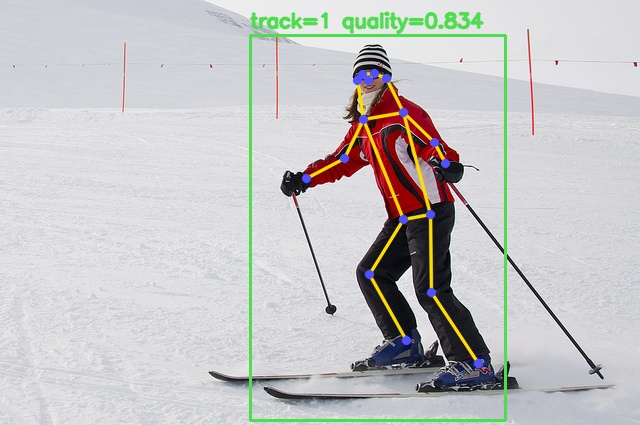

In [9]:
from IPython.display import Image, display

COCO_SKELETON = (
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 12),
    (5, 11), (6, 12), (5, 6), (5, 7), (7, 9),
    (6, 8), (8, 10), (1, 2), (0, 1), (0, 2),
    (1, 3), (2, 4), (3, 5), (4, 6),
)
KEYPOINT_THRESHOLD = 0.3

def draw_pose(
    frame: np.ndarray,
    bbox_xyxy: np.ndarray,
    keypoints: np.ndarray,
    threshold: float = KEYPOINT_THRESHOLD,
) -> np.ndarray:
    canvas = frame.copy()
    x1, y1, x2, y2 = bbox_xyxy.astype(int)
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (80, 220, 80), 2)

    for start, end in COCO_SKELETON:
        if keypoints[start, 2] >= threshold and keypoints[end, 2] >= threshold:
            start_xy = tuple(np.rint(keypoints[start, :2]).astype(int))
            end_xy = tuple(np.rint(keypoints[end, :2]).astype(int))
            cv2.line(canvas, start_xy, end_xy, (0, 220, 255), 2, cv2.LINE_AA)

    for x, y, confidence in keypoints:
        if confidence >= threshold:
            cv2.circle(
                canvas, (int(round(x)), int(round(y))), 4, (255, 80, 80), -1,
                cv2.LINE_AA,
            )

    cv2.putText(
        canvas, f"track={person_input['track_id']} quality={pose_quality:.3f}",
        (x1, max(24, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.65,
        (80, 220, 80), 2, cv2.LINE_AA,
    )
    return canvas

pose_visualization_bgr = draw_pose(
    frame_bgr, person_input["bbox_xyxy"], keypoints_xyc
)
encoded, visualization_buffer = cv2.imencode(".jpg", pose_visualization_bgr)
if not encoded:
    raise RuntimeError("Failed to encode pose visualization")
display(Image(data=visualization_buffer.tobytes()))

# 8. 지연시간과 출력 검증

session warm-up 후 순수 ONNX 추론 시간을 반복 측정한다. 전처리와 후처리 시간은 포함하지 않는다.

In [10]:
import time

WARMUP_RUNS = 5
BENCHMARK_RUNS = 50

for _ in range(WARMUP_RUNS):
    pose_session.run(pose_output_names, {pose_input_name: pose_input_tensor})

latency_ms = []
for _ in range(BENCHMARK_RUNS):
    started_at = time.perf_counter()
    pose_session.run(pose_output_names, {pose_input_name: pose_input_tensor})
    latency_ms.append((time.perf_counter() - started_at) * 1000.0)

latency_ms = np.asarray(latency_ms, dtype=np.float64)
frame_width = person_input["frame_width"]
frame_height = person_input["frame_height"]
coordinates_in_frame = (
    (keypoints_xyc[:, 0] >= 0)
    & (keypoints_xyc[:, 0] < frame_width)
    & (keypoints_xyc[:, 1] >= 0)
    & (keypoints_xyc[:, 1] < frame_height)
)

assert pose_input_tensor.shape == (1, 3, 256, 192)
assert pose_input_tensor.dtype == np.float32
assert keypoints_xyc.shape == (17, 3)
assert np.isfinite(keypoints_xyc).all()
assert np.all((keypoints_xyc[:, 2] >= 0.0) & (keypoints_xyc[:, 2] <= 1.0))
assert coordinates_in_frame.all()

print(f"Warm-up runs: {WARMUP_RUNS}")
print(f"Benchmark runs: {BENCHMARK_RUNS}")
print(f"Inference median: {np.median(latency_ms):.3f} ms")
print(f"Inference p90: {np.percentile(latency_ms, 90):.3f} ms")
print(f"Inference min/max: {latency_ms.min():.3f}/{latency_ms.max():.3f} ms")
print(f"Visible keypoints (c >= {KEYPOINT_THRESHOLD}): {(keypoints_xyc[:, 2] >= KEYPOINT_THRESHOLD).sum()}/17")
print(f"Coordinates inside frame: {coordinates_in_frame.sum()}/17")
print("M-03 output validation: PASS")

Warm-up runs: 5
Benchmark runs: 50
Inference median: 3.744 ms
Inference p90: 4.136 ms
Inference min/max: 3.580/4.459 ms
Visible keypoints (c >= 0.3): 17/17
Coordinates inside frame: 17/17
M-03 output validation: PASS


# 9. 완료 checkpoint

RTMPose-t ONNX session에서 Person Detection bbox를 받아 원본 frame 좌표의 `keypoints_xyc[17]`와 `pose_quality`를 생성했다. 다음 단계에서는 실제 M-01 detection/tracking 출력에 이 함수를 연결하고, `track_id`별 pose sequence를 M-04에 전달한다.